In [1]:
import sys, os

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

In [ ]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="optuna.distributions")

In [2]:
import pandas as pd
from src.get_data import load_data
from src.train.poisson_baseline.baseline_main import (
    fit_poisson_glm,
    fit_poisson_xgboost,
)
from src.train.poisson_nn.nn_main import (
    fit_poisson_nn,
    fit_poisson_nn_transfer_learning,
)
from src.train.training import run_experiment
from src.visualisation import (
    compare_models_for_cell,
    compare_r2_across_cells,
    compare_models_pairwise_r2,
    journal_plot_pack,
)
from src.train.poisson_nn.nn_models import CNNExtractor, RNNExtractor
from sklearn.preprocessing import StandardScaler

In [3]:
BASE_MODEL_DIR = "../resources/models/simulated"
BASE_RESULTS_DIR = "../resources/results/simulated"
FORCE_EXPERIMENTS = True

filenames = ["test1.mat", "test2.mat", "test3.mat", "test4.mat"]
X, Y, cell_ids, rec_ids = load_data("../resources/data/simulated", filenames)

In [4]:
X.shape, Y.shape, cell_ids.shape, rec_ids.shape

((5, 60000), (60000,), (60000,), (60000,))

### Baseline models (GLM and XGBoost)

In [5]:
# Baseline models: Poisson GLM with grid search
glm_results = run_experiment(
    "GLM",
    fit_poisson_glm,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\simulated\GLM.pkl


In [6]:
# Fit without grid search
glm_nogs_results = run_experiment(
    "GLM-NoGS",
    fit_poisson_glm,
    {"grid_search": False, "alpha": 0.1},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\simulated\GLM-NoGS.pkl


In [7]:
glm_results["best_params"]

{0.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 1.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 2.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 3.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 4.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 10.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 11.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 12.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 13.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 14.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 25.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 26.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 27.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 28.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 29.0: {'model_params': {'alpha': 0.01}, 'trainer_params': {}},
 45.0: {'model_params': {'alpha': 0.01}, 'tra

In [8]:
# Poisson XGBoost with grid search
xgboost_results = run_experiment(
    "XGBoost",
    fit_poisson_xgboost,
    {"grid_search": True},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\simulated\XGBoost.pkl


In [9]:
# Poisson XGBoost without grid search
xgboost_nogs_results = run_experiment(
    "XGBoost-NoGS",
    fit_poisson_xgboost,
    {"grid_search": False},
    X,
    Y,
    cell_ids,
    scaler=StandardScaler,
    plot=True,
    save_models=True,
    base_models_dir=BASE_MODEL_DIR,
    base_results_dir=BASE_RESULTS_DIR,
)

[run_experiment] Loading cached results from ..\resources\models\simulated\XGBoost-NoGS.pkl


In [10]:
xgboost_results["best_params"]

{0.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 1.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 2.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 3.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 4.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 10.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 11.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 12.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estimators': 200},
  'trainer_params': {}},
 13.0: {'model_params': {'max_depth': 3,
   'learning_rate': 0.1,
   'n_estim

### Extractor factory

In [11]:
def make_extractor(extractor_name, n_features):
    if extractor_name == "CNN":
        return CNNExtractor(
            n_features=n_features,
            channels=16,
            kernel=3,
            num_layers=3,
        )
    elif extractor_name == "RNN":
        return RNNExtractor(
            n_features=n_features,
            hidden_dim=32,
            num_layers=2,
        )
    elif extractor_name == "MLP":
        return None
    else:
        raise ValueError(f"Unknown extractor_name: {extractor_name}")


extractor_names = ["MLP", "CNN", "RNN"]

### Per-cell Neural Networks (MLP + CNN + RNN, GS + No-GS)

In [ ]:
nn_model_param_grid_base = {
    "hidden_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ]
}
nn_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4, 1e-3],
}

percell_results = {name: {} for name in extractor_names}

# Grid-search versions
for name in extractor_names:
    print(f"\n=== Per-Cell NN (GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        model_param_grid = nn_model_param_grid_base
    else:
        model_param_grid = {"extractor": [extractor]}

    res = run_experiment(
        f"NN-PerCell-{name}",
        fit_poisson_nn,
        {
            "batch_size": "auto",
            "epochs": 30,
            "grid_search": True,
            "k_folds": 2,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": nn_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    percell_results[name]["GS"] = res

[I 2026-03-30 13:36:53,538] A new study created in memory with name: no-name-a13b3cdb-1be8-442b-9bd3-b0380352d99e



=== Per-Cell NN (GS) with MLP extractor ===


c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (16,) which is of type tuple.
  optuna_warn(message)
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (32,) which is of type tuple.
  optuna_warn(message)
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64,) which is of type tuple.
  optuna_warn(message)
c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\optuna\distributions.py:502: UserWarning: Choices for 

In [ ]:
# No-grid-search versions (fixed extractor)
for name in extractor_names:
    print(f"\n=== Per-Cell NN (No GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        # MLP: use fixed hidden_sizes and l1_lambda as in original
        kwargs = {
            "batch_size": "auto",
            "hidden_sizes": [64, 32],
            "l1_lambda": 0.0,
            "grid_search": False,
            "verbose": True,
        }
    else:
        # CNN/RNN: fixed extractor, no grid search
        kwargs = {
            "batch_size": "auto",
            "model_param_grid": {"extractor": extractor},
            "l1_lambda": 0.0,
            "grid_search": False,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-PerCell-{name}-NoGS",
        fit_poisson_nn,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    percell_results[name]["NoGS"] = res


=== Per-Cell NN (No GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-MLP-NoGS.pkl

=== Per-Cell NN (No GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-CNN-NoGS.pkl

=== Per-Cell NN (No GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-PerCell-RNN-NoGS.pkl


### Transfer Learning: shared hidden (MLP + CNN + RNN, GS + No-GS)

In [ ]:
tl_model_param_grid_base = {
    "hidden_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ]
}
tl_trainer_param_grid = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

tl_results = {
    "shared_hidden": {name: {} for name in extractor_names},
    "shared_nonlinear_heads": {name: {} for name in extractor_names},
    "shared_first_layer": {name: {} for name in extractor_names},
}

# Shared hidden: GS
for name in extractor_names:
    print(f"\n=== TL SharedHidden (GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        # MLP baseline: no custom extractor, but keys must still exist
        model_param_grid = {
            "hidden_sizes": tl_model_param_grid_base["hidden_sizes"],
            "shared_sizes": tl_model_param_grid_base["hidden_sizes"],
            "shared_extractor": [None],
        }
    else:
        # CNN/RNN: fixed shared extractor, still vary hidden sizes
        model_param_grid = {
            "hidden_sizes": tl_model_param_grid_base["hidden_sizes"],
            "shared_sizes": tl_model_param_grid_base["hidden_sizes"],
            "shared_extractor": [extractor],
        }

    res = run_experiment(
        f"NN-TL-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_trainer_param_grid,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    tl_results["shared_hidden"][name]["GS"] = res


=== TL SharedHidden (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-MLP.pkl

=== TL SharedHidden (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-CNN.pkl

=== TL SharedHidden (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-RNN.pkl


In [ ]:
# Shared hidden: No-GS
for name in extractor_names:
    print(f"\n=== TL SharedHidden (No GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        kwargs = {
            "batch_size": "auto",
            "hidden_sizes": (64, 32),
            "l1_lambda": 1e-4,
            "grid_search": False,
            "verbose": True,
        }
    else:
        kwargs = {
            "batch_size": "auto",
            "model_params": {
                "shared_extractor": extractor,
                "hidden_sizes": (64, 32),
            },
            "l1_lambda": 1e-4,
            "grid_search": False,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-TL-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    tl_results["shared_hidden"][name]["NoGS"] = res


=== TL SharedHidden (No GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-MLP-NoGS.pkl

=== TL SharedHidden (No GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-CNN-NoGS.pkl

=== TL SharedHidden (No GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-RNN-NoGS.pkl


### Transfer Learning: shared nonlinear heads (MLP + CNN + RNN, GS + No-GS)

In [ ]:
tl_model_param_grid_nonlinear_base = {
    "shared_sizes": [
        (16,),
        (32,),
        (64,),
        (64, 32),
    ],
    "head_sizes": [
        (32, 16),
        (64, 32),
    ],
}
tl_trainer_param_grid_nonlinear = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# Nonlinear heads: GS
for name in extractor_names:
    print(f"\n=== TL NonlinearHeads (GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        model_param_grid = {
            "shared_sizes": tl_model_param_grid_nonlinear_base["shared_sizes"],
            "head_sizes": tl_model_param_grid_nonlinear_base["head_sizes"],
            "shared_extractor": [None],
        }
    else:
        model_param_grid = {
            "shared_sizes": tl_model_param_grid_nonlinear_base["shared_sizes"],
            "head_sizes": tl_model_param_grid_nonlinear_base["head_sizes"],
            "shared_extractor": [extractor],
        }

    res = run_experiment(
        f"NN-TL-NonlinearHeads-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "shared_nonlinear_heads",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_trainer_param_grid_nonlinear,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    tl_results["shared_nonlinear_heads"][name]["GS"] = res


=== TL NonlinearHeads (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-NonlinearHeads-MLP.pkl

=== TL NonlinearHeads (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-NonlinearHeads-CNN.pkl

=== TL NonlinearHeads (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-NonlinearHeads-RNN.pkl


In [ ]:
# Nonlinear heads: No-GS
for name in extractor_names:
    print(f"\n=== TL NonlinearHeads (No GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        # MLP baseline: no extractor, but must include ALL keys
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "shared_nonlinear_heads",
            "model_params": {
                "shared_sizes": (64,),
                "head_sizes": (64, 32),
                "shared_extractor": None,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }
    else:
        # CNN/RNN: fixed extractor, but still must include ALL keys
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "shared_nonlinear_heads",
            "model_params": {
                "shared_sizes": (64,),
                "head_sizes": (64, 32),
                "shared_extractor": extractor,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-TL-NonlinearHeads-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    tl_results["shared_nonlinear_heads"][name]["NoGS"] = res


=== TL NonlinearHeads (No GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-NonlinearHeads-MLP-NoGS.pkl

=== TL NonlinearHeads (No GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-NonlinearHeads-CNN-NoGS.pkl

=== TL NonlinearHeads (No GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-NonlinearHeads-RNN-NoGS.pkl


### Transfer Learning: shared first layer (MLP + CNN + RNN, GS + No-GS)

In [ ]:
tl_model_param_grid_firstlayer_base = {
    "shared_dim": [16, 32, 64],
    "head_sizes": [
        (32, 16),
        (64, 32),
    ],
}
tl_trainer_param_grid_firstlayer = {
    "l1_lambda": [0.0, 1e-5, 1e-4],
}

# First layer: GS
for name in extractor_names:
    print(f"\n=== TL FirstLayer (GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        model_param_grid = {
            "shared_dim": tl_model_param_grid_firstlayer_base["shared_dim"],
            "head_sizes": tl_model_param_grid_firstlayer_base["head_sizes"],
            "shared_extractor": [None],
        }
    else:
        model_param_grid = {
            "shared_dim": tl_model_param_grid_firstlayer_base["shared_dim"],
            "head_sizes": tl_model_param_grid_firstlayer_base["head_sizes"],
            "shared_extractor": [extractor],
        }

    res = run_experiment(
        f"NN-TL-FirstLayer-{name}",
        fit_poisson_nn_transfer_learning,
        {
            "batch_size": "auto",
            "grid_search": True,
            "model_type": "shared_first_layer",
            "model_param_grid": model_param_grid,
            "trainer_param_grid": tl_trainer_param_grid_firstlayer,
        },
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    tl_results["shared_first_layer"][name]["GS"] = res


=== TL FirstLayer (GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-FirstLayer-MLP.pkl

=== TL FirstLayer (GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-FirstLayer-CNN.pkl

=== TL FirstLayer (GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-FirstLayer-RNN.pkl


In [ ]:
# First layer: No-GS
for name in extractor_names:
    print(f"\n=== TL FirstLayer (No GS) with {name} extractor ===")
    extractor = make_extractor(name, X.shape[0])

    if extractor is None:
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "shared_first_layer",
            "model_params": {
                "shared_dim": 64,
                "head_sizes": (64, 32),
                "shared_extractor": None,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }
    else:
        kwargs = {
            "batch_size": "auto",
            "grid_search": False,
            "model_type": "shared_first_layer",
            "model_params": {
                "shared_dim": 64,
                "head_sizes": (64, 32),
                "shared_extractor": extractor,
            },
            "l1_lambda": 1e-4,
            "verbose": True,
        }

    res = run_experiment(
        f"NN-TL-FirstLayer-{name}-NoGS",
        fit_poisson_nn_transfer_learning,
        kwargs,
        X,
        Y,
        cell_ids,
        scaler=StandardScaler,
        plot=True,
        save_models=True,
        force=FORCE_EXPERIMENTS,
        base_models_dir=BASE_MODEL_DIR,
        base_results_dir=BASE_RESULTS_DIR,
    )
    tl_results["shared_first_layer"][name]["NoGS"] = res


=== TL FirstLayer (No GS) with MLP extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-FirstLayer-MLP-NoGS.pkl

=== TL FirstLayer (No GS) with CNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-FirstLayer-CNN-NoGS.pkl

=== TL FirstLayer (No GS) with RNN extractor ===
[run_experiment] Loading cached results from ..\resources\models\simulated\NN-TL-FirstLayer-RNN-NoGS.pkl


### Build comparison lists for GS and No-GS

In [ ]:
# Grid search results for all models
model_results_gs = [
    (glm_results["results"], "GLM"),
    (xgboost_results["results"], "XGBoost"),
    (percell_results["MLP"]["GS"]["results"], "NN-PerCell-MLP"),
    (percell_results["CNN"]["GS"]["results"], "NN-PerCell-CNN"),
    (percell_results["RNN"]["GS"]["results"], "NN-PerCell-RNN"),
    (tl_results["shared_hidden"]["MLP"]["GS"]["results"], "NN-TL-MLP"),
    (tl_results["shared_hidden"]["CNN"]["GS"]["results"], "NN-TL-CNN"),
    (tl_results["shared_hidden"]["RNN"]["GS"]["results"], "NN-TL-RNN"),
    (
        tl_results["shared_nonlinear_heads"]["MLP"]["GS"]["results"],
        "NN-TL-NonlinearHeads-MLP",
    ),
    (
        tl_results["shared_nonlinear_heads"]["CNN"]["GS"]["results"],
        "NN-TL-NonlinearHeads-CNN",
    ),
    (
        tl_results["shared_nonlinear_heads"]["RNN"]["GS"]["results"],
        "NN-TL-NonlinearHeads-RNN",
    ),
    (tl_results["shared_first_layer"]["MLP"]["GS"]["results"], "NN-TL-FirstLayer-MLP"),
    (tl_results["shared_first_layer"]["CNN"]["GS"]["results"], "NN-TL-FirstLayer-CNN"),
    (tl_results["shared_first_layer"]["RNN"]["GS"]["results"], "NN-TL-FirstLayer-RNN"),
]

cells_gs = sorted(glm_results["results"].keys())

In [ ]:
data_rows = []
for cell in cells_gs:
    row = {"cell": cell}
    for results, name in model_results_gs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf_gs = pd.DataFrame(data_rows)
df_test_perf_gs

,cell,GLM,XGBoost,NN-PerCell-MLP,NN-PerCell-CNN,NN-PerCell-RNN,NN-TL-MLP,NN-TL-CNN,NN-TL-RNN,NN-TL-NonlinearHeads-MLP,NN-TL-NonlinearHeads-CNN,NN-TL-NonlinearHeads-RNN,NN-TL-FirstLayer-MLP,NN-TL-FirstLayer-CNN,NN-TL-FirstLayer-RNN
0,0.0,0.511454,0.765825,0.832518,0.890580,0.882208,0.158425,0.587975,0.404645,0.549119,0.866707,0.844892,0.559137,0.853351,0.852429
1,1.0,0.506373,0.763823,0.896510,0.900897,0.887200,0.157523,0.491390,0.562799,0.541143,0.875795,0.837229,0.562402,0.859135,0.859684
2,2.0,0.514983,0.763364,0.884355,0.906921,0.878078,0.131750,0.433334,0.627957,0.558491,0.869735,0.816493,0.566616,0.841114,0.843346
3,3.0,0.497466,0.759938,0.897288,0.921590,0.900323,0.116665,0.613202,0.534352,0.525459,0.871433,0.873777,0.581132,0.851844,0.855757
4,4.0,0.501561,0.756861,0.893300,0.906195,0.897404,0.122396,0.491812,0.590525,0.537052,0.873700,0.858563,0.545011,0.846307,0.838314
5,10.0,0.412066,0.704449,0.782658,0.762587,0.773867,0.031383,0.103042,0.457065,0.549419,0.691144,0.748146,0.497838,0.616384,0.745855
6,11.0,0.428756,0.716208,0.775140,0.761039,0.791986,0.040938,0.268081,0.528244,0.473498,0.700012,0.755043,0.460328,0.633480,0.746123
7,12.0,0.467753,0.727279,0.806203,0.769909,0.794119,0.076343,-0.222072,0.502740,0.553869,0.719005,0.766235,0.484531,0.656445,0.738841
8,13.0,0.448820,0.718115,0.788067,0.751228,0.792262,0.064560,0.262780,0.553238,0.558799,0.710172,0.755430,0.519714,0.647552,0.743631
9,14.0,0.425786,0.684994,0.766794,0.749717,0.768773,0.034331,0.065316,0.505488,0.509990,0.655181,0.729668,0.467776,0.638735,0.730495


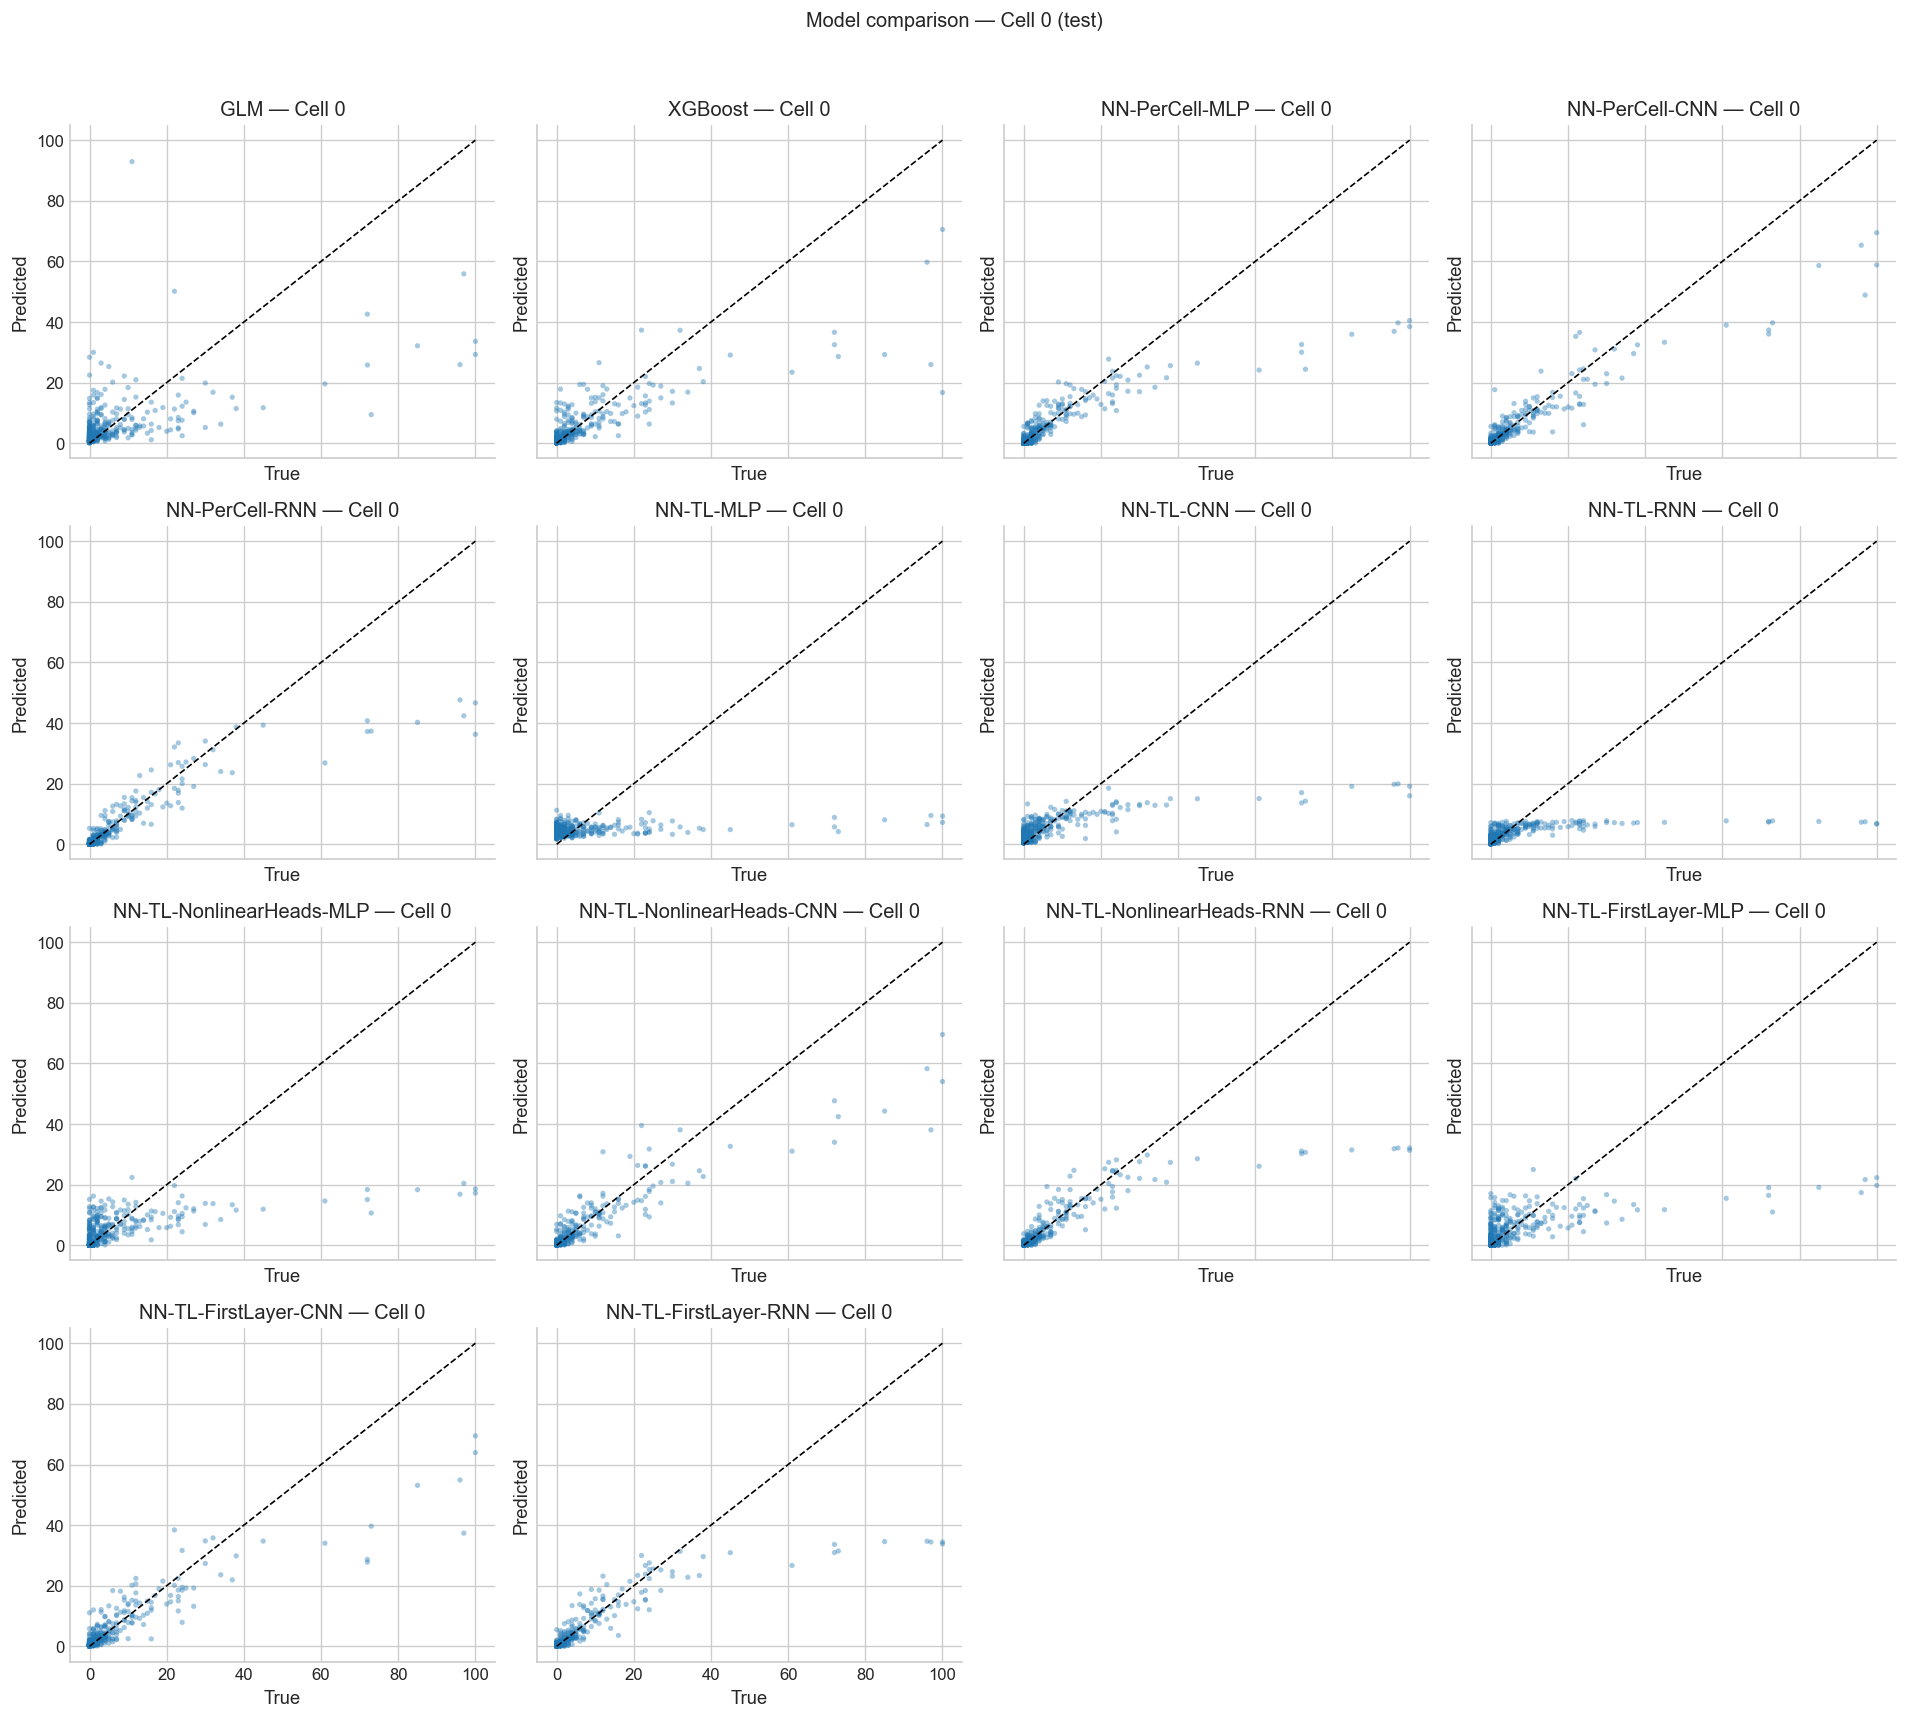

In [ ]:
compare_models_for_cell(model_results_gs, cell=0, split="test")

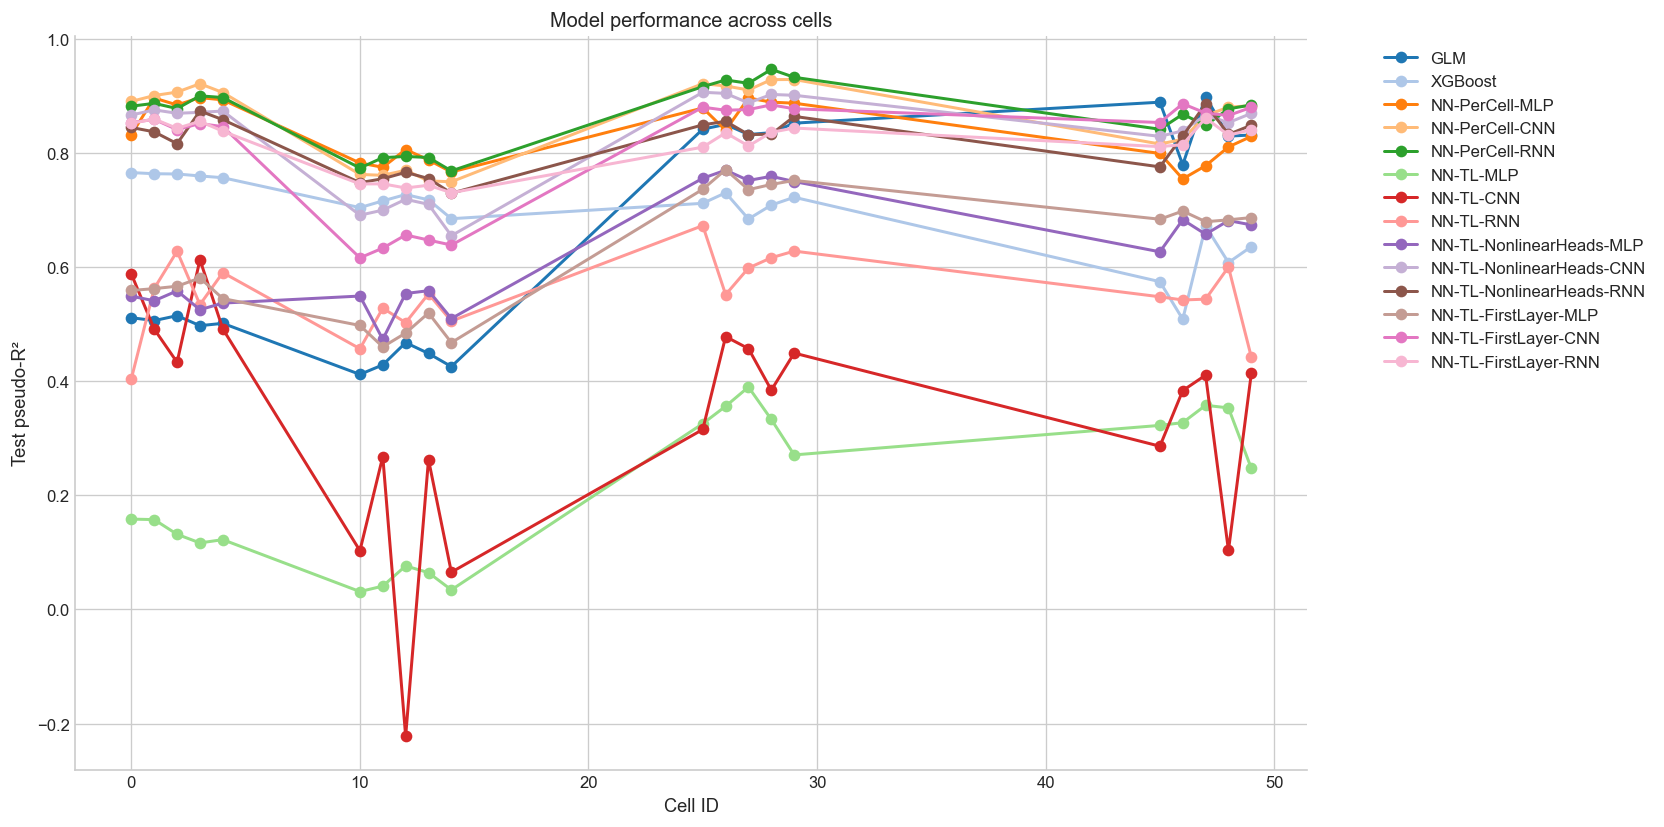

In [ ]:
compare_r2_across_cells(model_results_gs, split="test")

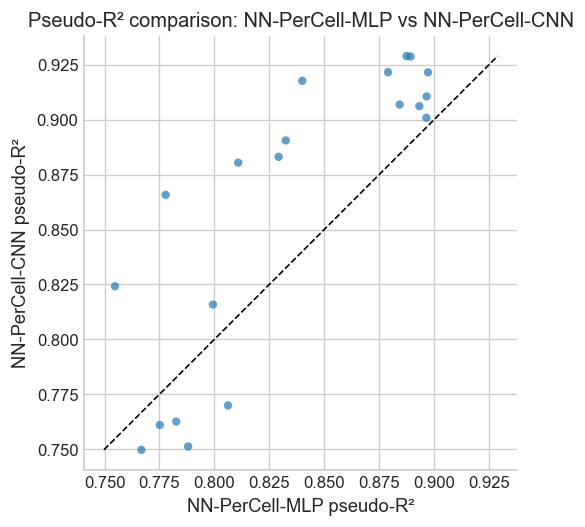

In [ ]:
compare_models_pairwise_r2(
    model_results_gs,
    "NN-PerCell-MLP",
    "NN-PerCell-CNN",
)

In [ ]:
# No-grid-search results for all models
model_results_nogs = [
    (glm_nogs_results["results"], "GLM (No GS)"),
    (xgboost_nogs_results["results"], "XGBoost (No GS)"),
    (percell_results["MLP"]["NoGS"]["results"], "NN-PerCell-MLP (No GS)"),
    (percell_results["CNN"]["NoGS"]["results"], "NN-PerCell-CNN (No GS)"),
    (percell_results["RNN"]["NoGS"]["results"], "NN-PerCell-RNN (No GS)"),
    (tl_results["shared_hidden"]["MLP"]["NoGS"]["results"], "NN-TL-MLP (No GS)"),
    (tl_results["shared_hidden"]["CNN"]["NoGS"]["results"], "NN-TL-CNN (No GS)"),
    (tl_results["shared_hidden"]["RNN"]["NoGS"]["results"], "NN-TL-RNN (No GS)"),
    (
        tl_results["shared_nonlinear_heads"]["MLP"]["NoGS"]["results"],
        "NN-TL-NonlinearHeads-MLP (No GS)",
    ),
    (
        tl_results["shared_nonlinear_heads"]["CNN"]["NoGS"]["results"],
        "NN-TL-NonlinearHeads-CNN (No GS)",
    ),
    (
        tl_results["shared_nonlinear_heads"]["RNN"]["NoGS"]["results"],
        "NN-TL-NonlinearHeads-RNN (No GS)",
    ),
    (
        tl_results["shared_first_layer"]["MLP"]["NoGS"]["results"],
        "NN-TL-FirstLayer-MLP (No GS)",
    ),
    (
        tl_results["shared_first_layer"]["CNN"]["NoGS"]["results"],
        "NN-TL-FirstLayer-CNN (No GS)",
    ),
    (
        tl_results["shared_first_layer"]["RNN"]["NoGS"]["results"],
        "NN-TL-FirstLayer-RNN (No GS)",
    ),
]

cells_nogs = sorted(glm_nogs_results["results"].keys())

In [ ]:
data_rows = []
for cell in cells_nogs:
    row = {"cell": cell}
    for results, name in model_results_nogs:
        row[name] = results[cell]["test"]["pseudo_r2"]
    data_rows.append(row)

df_test_perf_nogs = pd.DataFrame(data_rows)
df_test_perf_nogs

,cell,GLM (No GS),XGBoost (No GS),NN-PerCell-MLP (No GS),NN-PerCell-CNN (No GS),NN-PerCell-RNN (No GS),NN-TL-MLP (No GS),NN-TL-CNN (No GS),NN-TL-RNN (No GS),NN-TL-NonlinearHeads-MLP (No GS),NN-TL-NonlinearHeads-CNN (No GS),NN-TL-NonlinearHeads-RNN (No GS),NN-TL-FirstLayer-MLP (No GS),NN-TL-FirstLayer-CNN (No GS),NN-TL-FirstLayer-RNN (No GS)
0,0.0,0.495828,0.787478,0.851989,0.896894,0.864484,0.211956,0.150448,-0.030503,0.495527,0.446086,0.142980,0.483865,0.248548,0.111305
1,1.0,0.491330,0.776923,0.895906,0.892760,0.880355,0.178611,0.209853,-0.047806,0.505884,0.421405,0.133868,0.515325,0.213724,0.113093
2,2.0,0.487759,0.777255,0.853929,0.882363,0.874309,0.191475,-0.033765,-0.006080,0.501622,0.447970,0.139258,0.516313,0.246107,0.120200
3,3.0,0.481392,0.781882,0.893052,0.907013,0.889629,0.211022,-0.019437,-0.061820,0.496912,0.432994,0.128254,0.498127,0.235435,0.108050
4,4.0,0.472272,0.763104,0.911804,0.896849,0.885859,0.205385,0.115087,-0.030645,0.496095,0.448598,0.137791,0.467130,0.238118,0.115240
5,10.0,0.413206,0.690789,0.783858,0.737074,0.770889,0.049847,-0.816317,-0.048111,0.425688,0.094599,0.245627,0.451921,0.206118,0.218183
6,11.0,0.439885,0.710068,0.774349,0.759015,0.783032,0.137727,-0.420703,-0.164483,0.434183,0.116025,0.252842,0.484760,0.190458,0.233714
7,12.0,0.454806,0.729184,0.800322,0.776468,0.798015,0.084478,-1.029525,-0.066309,0.425341,0.088850,0.249712,0.491675,0.188164,0.229898
8,13.0,0.438039,0.709677,0.797250,0.775328,0.785593,0.143432,-1.021263,-0.132277,0.438519,0.122367,0.241305,0.485763,0.182867,0.227268
9,14.0,0.431220,0.694672,0.761559,0.734277,0.762404,0.170907,-0.793574,-0.014215,0.449995,0.086460,0.241603,0.508910,0.187545,0.239735


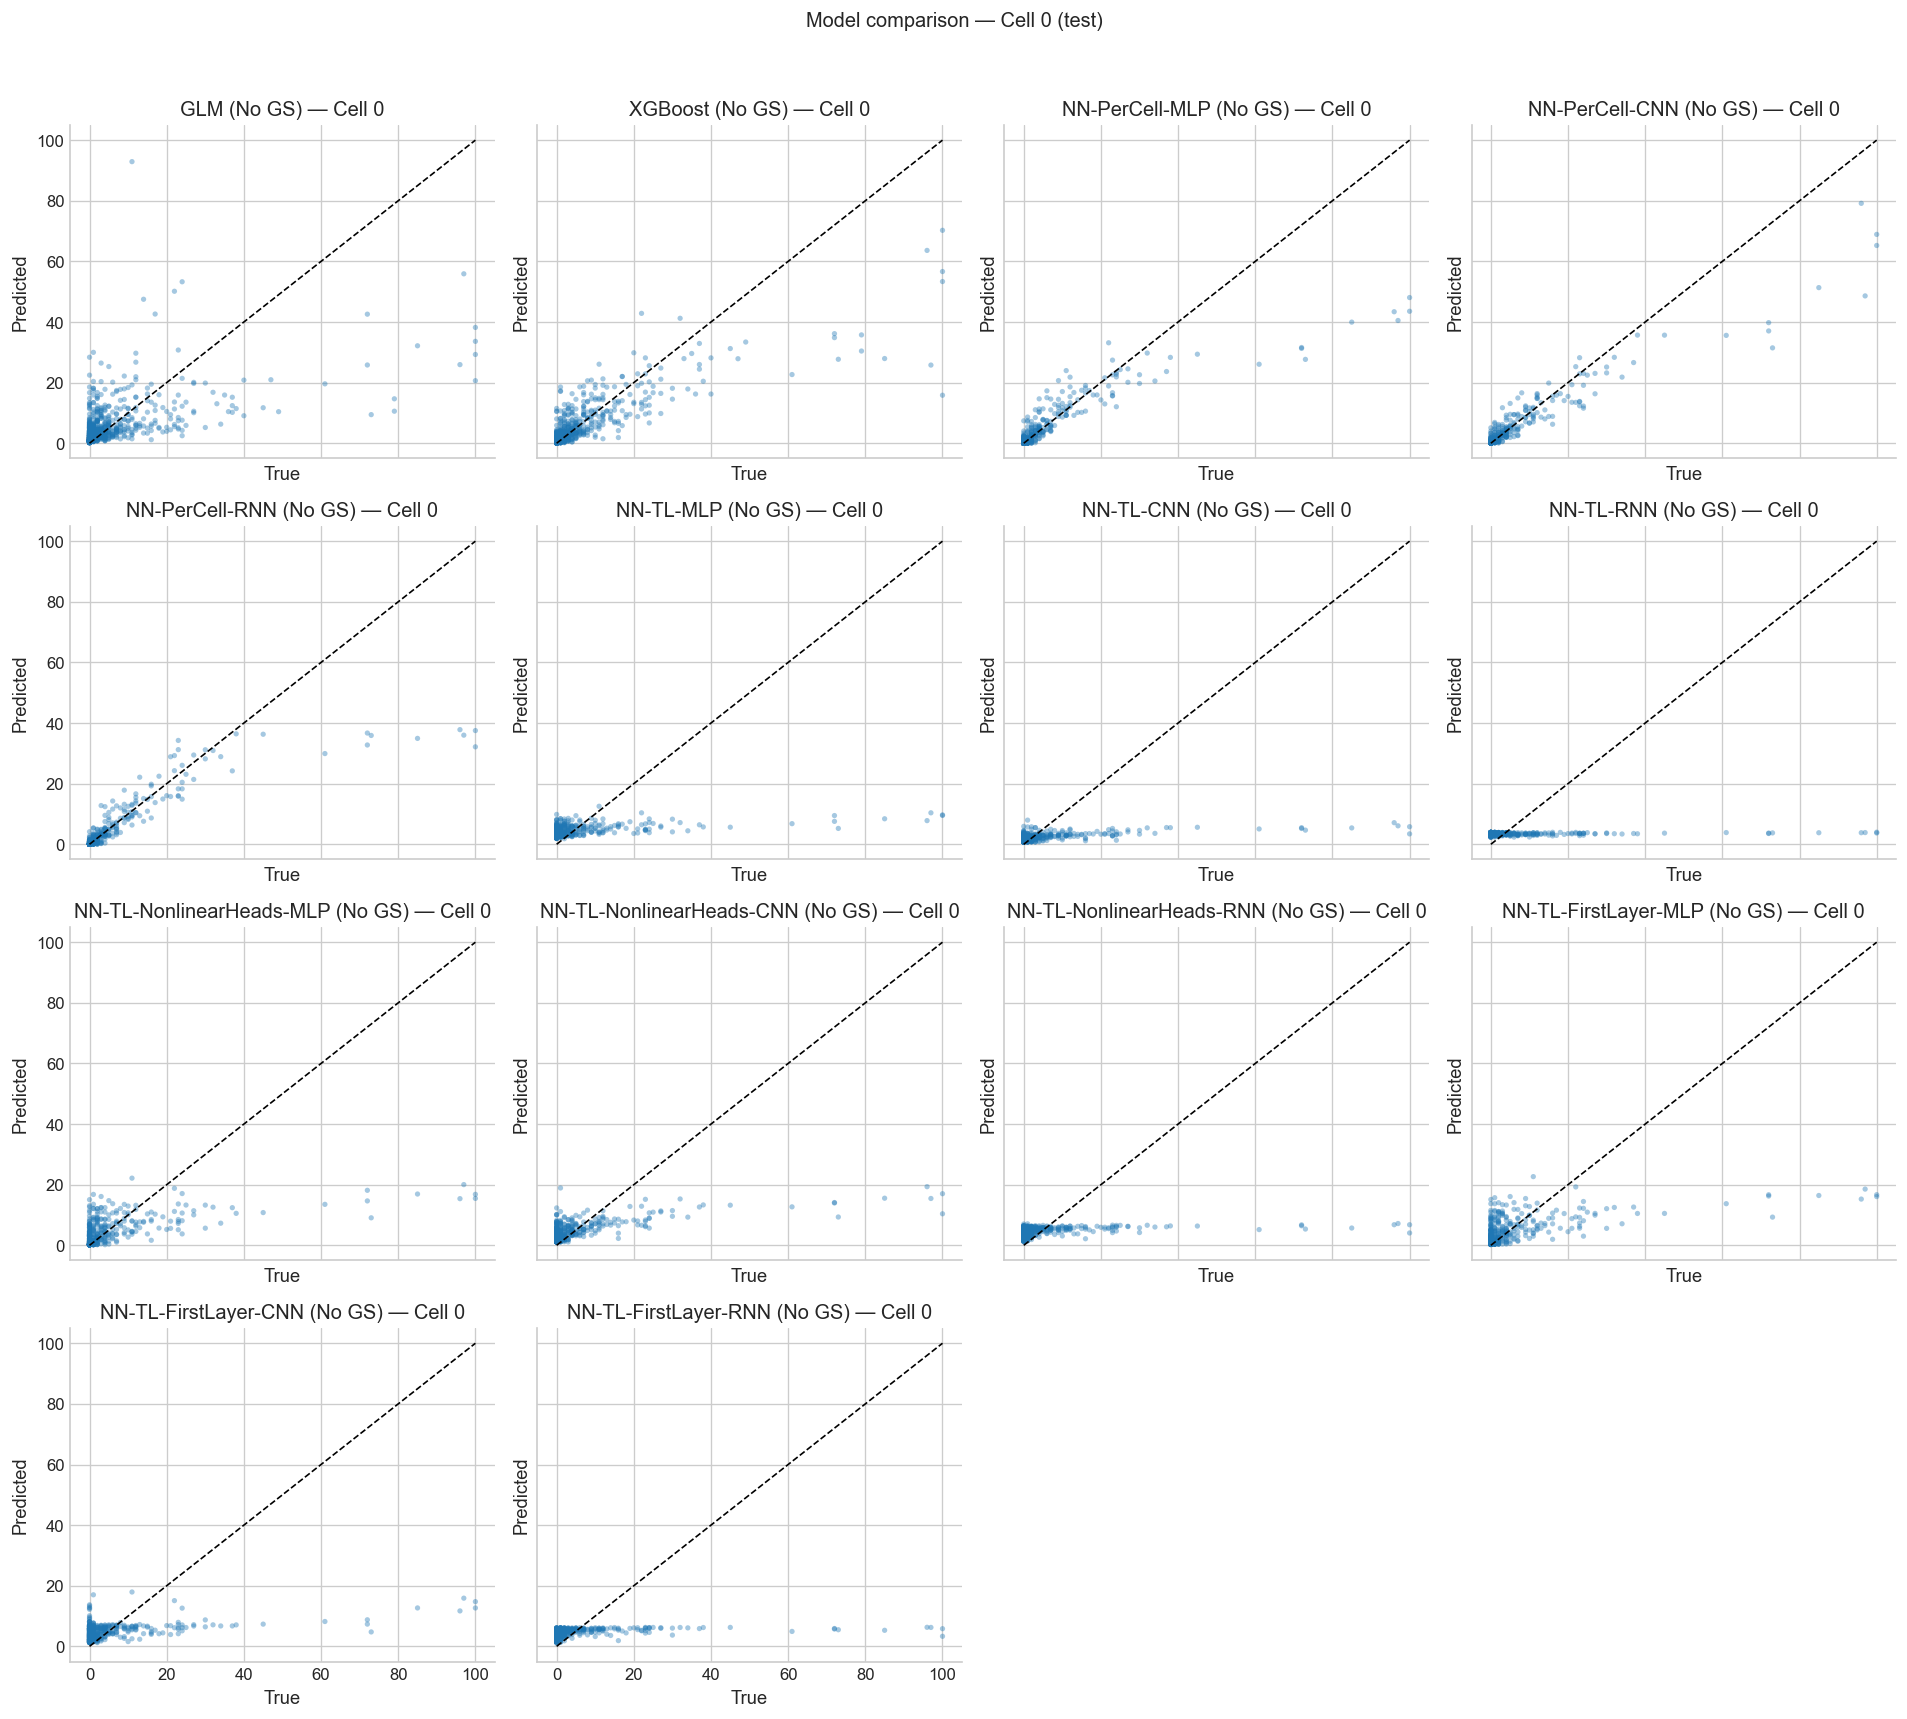

In [ ]:
compare_models_for_cell(model_results_nogs, cell=0, split="test")

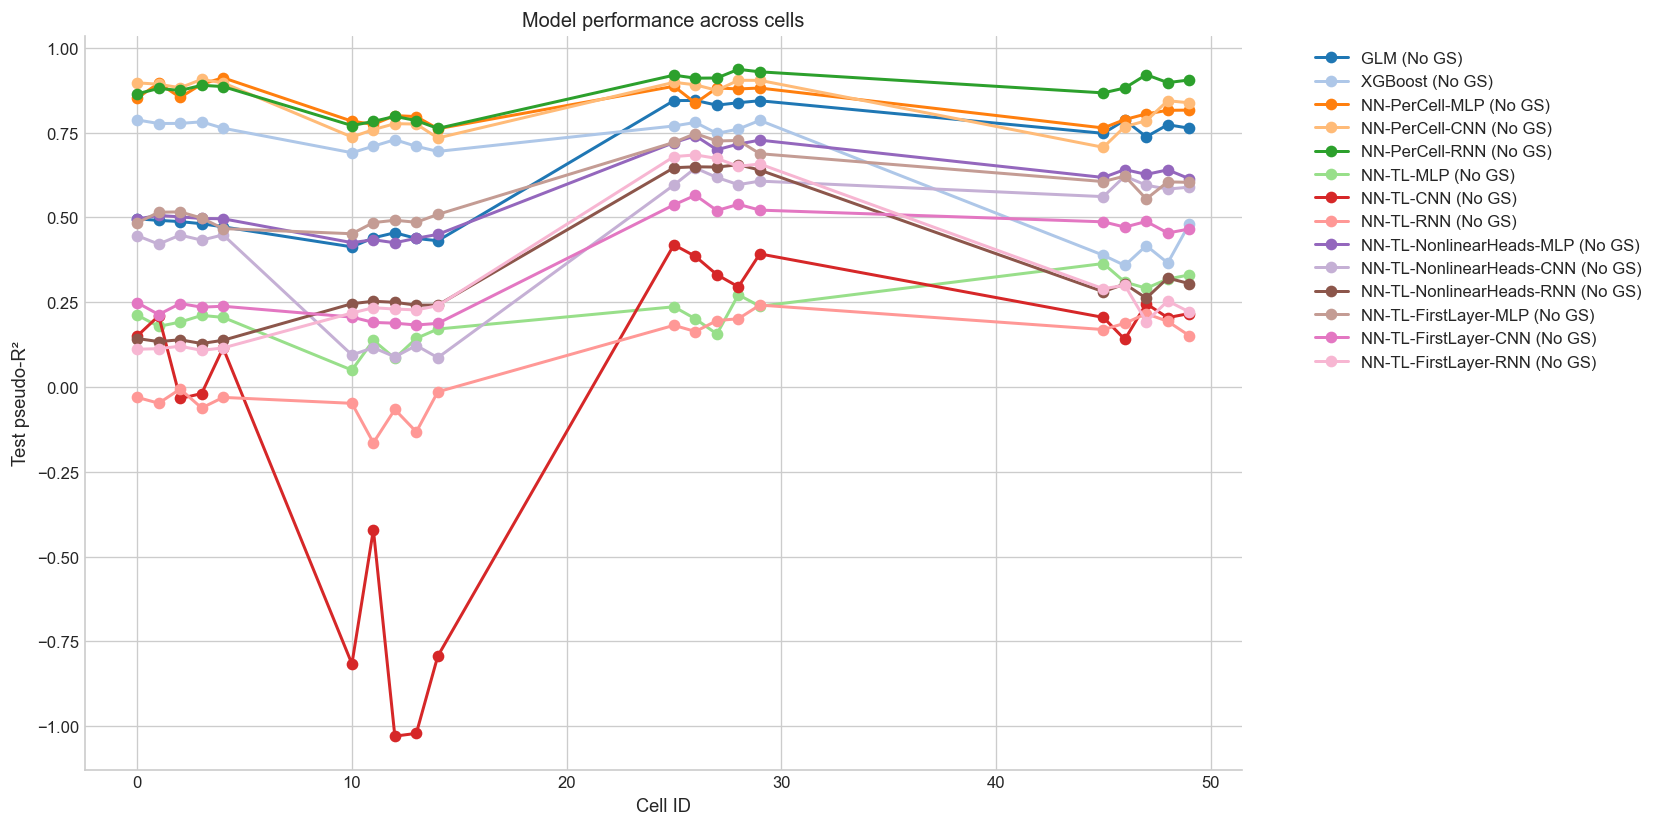

In [ ]:
compare_r2_across_cells(model_results_nogs, split="test")

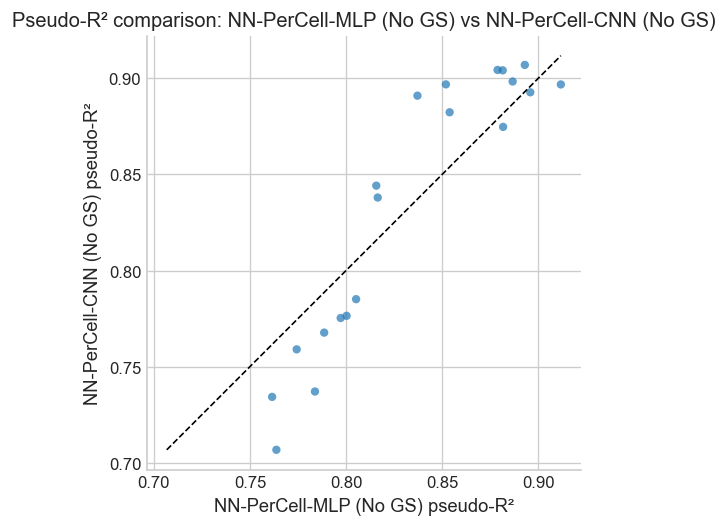

In [ ]:
compare_models_pairwise_r2(
    model_results_nogs,
    "NN-PerCell-MLP (No GS)",
    "NN-PerCell-CNN (No GS)",
)

In [ ]:
saved_paths = journal_plot_pack(
    model_results_gs,
    cells=cells_gs,
    split="test",
    base_dir=BASE_RESULTS_DIR,
)
print(f"Generated {len(saved_paths)} plots")
for p in saved_paths[-5:]:
    print(f"  {p}")

Generated 112 plots
  ..\resources\results\simulated\journal\pairwise_NN-TL-NonlinearHeads-RNN_vs_NN-TL-FirstLayer-CNN.png
  ..\resources\results\simulated\journal\pairwise_NN-TL-NonlinearHeads-RNN_vs_NN-TL-FirstLayer-RNN.png
  ..\resources\results\simulated\journal\pairwise_NN-TL-FirstLayer-MLP_vs_NN-TL-FirstLayer-CNN.png
  ..\resources\results\simulated\journal\pairwise_NN-TL-FirstLayer-MLP_vs_NN-TL-FirstLayer-RNN.png
  ..\resources\results\simulated\journal\pairwise_NN-TL-FirstLayer-CNN_vs_NN-TL-FirstLayer-RNN.png
